# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/atulpatel-net/FlyRank_ML_In/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [2]:
import duckdb
import pandas as pd
import numpy as np

from google.colab import userdata

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier


# ---------------------------------------------------------
# 1. Load FlyRank warehouse
# ---------------------------------------------------------

HF_TOKEN = userdata.get("HF_TOKEN")

con = duckdb.connect()

con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')"
)


# ---------------------------------------------------------
# 2. Recreate the Week-5/Week-6 dataset
# ---------------------------------------------------------

data = con.sql("""
WITH bounds AS (
    SELECT MAX(report_date) AS end_d
    FROM read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=*/data_0.parquet'
    )
),

features AS (
    SELECT
        client_hash_id,
        content_hash_id,

        SUM(
            CASE
                WHEN report_date BETWEEN end_d - INTERVAL 59 DAY
                                     AND end_d - INTERVAL 30 DAY
                THEN gsc_impressions
                ELSE 0
            END
        ) AS imp_prev30,

        SUM(
            CASE
                WHEN report_date BETWEEN end_d - INTERVAL 29 DAY
                                     AND end_d
                THEN gsc_impressions
                ELSE 0
            END
        ) AS imp_last30,

        SUM(
            CASE
                WHEN report_date BETWEEN end_d - INTERVAL 59 DAY
                                     AND end_d - INTERVAL 30 DAY
                THEN gsc_clicks
                ELSE 0
            END
        ) AS clk_prev30,

        AVG(
            CASE
                WHEN report_date BETWEEN end_d - INTERVAL 59 DAY
                                     AND end_d - INTERVAL 30 DAY
                THEN gsc_avg_position
            END
        ) AS pos_prev30

    FROM read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=*/data_0.parquet'
    ), bounds

    GROUP BY
        client_hash_id,
        content_hash_id
)

SELECT *
FROM features
WHERE imp_prev30 > 0
""").df()


# ---------------------------------------------------------
# 3. Target + features
# ---------------------------------------------------------

data["is_declining"] = (
    data["imp_last30"] < 0.8 * data["imp_prev30"]
).astype(int)

feature_cols = [
    "imp_prev30",
    "clk_prev30",
    "pos_prev30"
]

X = data[feature_cols]
y = data["is_declining"]
groups = data["client_hash_id"]


# ---------------------------------------------------------
# 4. Recreate the validated client-grouped split
# ---------------------------------------------------------

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]


# ---------------------------------------------------------
# 5. Recreate the validated Random Forest
# ---------------------------------------------------------

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Probability of the declining class
decline_probability = rf.predict_proba(X_test)[:, 1]


# ---------------------------------------------------------
# 6. Create the evaluation output
# ---------------------------------------------------------

queue = data.iloc[test_idx].copy()

queue["decline_probability"] = decline_probability

print("Dataset shape:", data.shape)
print("Evaluation rows:", len(queue))
print("Validated grouped F1: 0.735")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Dataset shape: (237429, 7)
Evaluation rows: 42558
Validated grouped F1: 0.735


In [3]:
# ---------------------------------------------------------
# 7. Build ranked action queue
# ---------------------------------------------------------

queue = queue.copy()

# Rank highest predicted decline risk first
queue = queue.sort_values(
    "decline_probability",
    ascending=False
).reset_index(drop=True)

queue["priority_rank"] = np.arange(1, len(queue) + 1)

# Initial action category
queue["recommended_action"] = np.select(
    [
        queue["decline_probability"] >= 0.80,
        queue["decline_probability"] >= 0.60
    ],
    [
        "Refresh / investigate first",
        "Review for possible refresh"
    ],
    default="Monitor"
)

print("Ranked queue created.")
print("Queue rows:", len(queue))

display(
    queue[
        [
            "priority_rank",
            "client_hash_id",
            "content_hash_id",
            "decline_probability",
            "recommended_action"
        ]
    ].head(20)
)

Ranked queue created.
Queue rows: 42558


,priority_rank,client_hash_id,content_hash_id,decline_probability,recommended_action
0,1,client_fef1a8f436438636,content_a184010a5cfdbb91,1.0,Refresh / investigate first
1,2,client_23a62021009f63c4,content_76caa7b1b7661b68,1.0,Refresh / investigate first
2,3,client_23a62021009f63c4,content_4c0b98537e05c2d6,1.0,Refresh / investigate first
3,4,client_23a62021009f63c4,content_8347275a5f4eb9f1,1.0,Refresh / investigate first
4,5,client_8ae2bfb5aa1ffa1e,content_0ab9ee4bc2a32e5c,1.0,Refresh / investigate first
5,6,client_e547b89c05043229,content_029b8d0a9b35deb9,1.0,Refresh / investigate first
6,7,client_e547b89c05043229,content_05a44b0d745333d6,1.0,Refresh / investigate first
7,8,client_a22068e339bf95f5,content_fca698e83fcf1e06,1.0,Refresh / investigate first
8,9,client_a22068e339bf95f5,content_b9dca2b8612276a4,1.0,Refresh / investigate first
9,10,client_a22068e339bf95f5,content_29dca2fe896d0991,1.0,Refresh / investigate first


In [4]:
# Inspect the signals used to explain the ranked queue

signal_summary = queue[
    [
        "imp_prev30",
        "clk_prev30",
        "pos_prev30",
        "decline_probability"
    ]
].describe(
    percentiles=[0.25, 0.50, 0.75]
).round(2)

display(signal_summary)

,imp_prev30,clk_prev30,pos_prev30,decline_probability
count,42558.00,42558.00,42558.00,42558.00
mean,1670.30,5.62,25.24,0.70
std,6315.36,29.74,16.31,0.22
min,1.00,0.00,0.00,0.00
25%,70.00,0.00,12.76,0.55
50%,299.00,0.00,22.35,0.75
75%,1250.00,3.00,33.73,0.88
max,585502.00,4066.00,191.00,1.00


In [5]:
# ---------------------------------------------------------
# 8. Add human-readable reason codes
# ---------------------------------------------------------

def get_reason_code(row):
    reasons = []

    # Model prioritization
    if row["decline_probability"] >= 0.80:
        reasons.append("HIGH_MODEL_RISK")
    elif row["decline_probability"] >= 0.60:
        reasons.append("MODERATE_MODEL_RISK")

    # Historical visibility
    if row["imp_prev30"] < 70:
        reasons.append("LOW_PRIOR_IMPRESSIONS")

    # Click signal
    if row["clk_prev30"] == 0:
        reasons.append("NO_PRIOR_CLICKS")

    # Search position signal
    if row["pos_prev30"] >= 33.73:
        reasons.append("WEAKER_PRIOR_POSITION")

    if not reasons:
        reasons.append("MODEL_PRIORITIZED")

    return "; ".join(reasons)


queue["reason_code"] = queue.apply(
    get_reason_code,
    axis=1
)

display(
    queue[
        [
            "priority_rank",
            "content_hash_id",
            "decline_probability",
            "recommended_action",
            "reason_code"
        ]
    ].head(20)
)

,priority_rank,content_hash_id,decline_probability,recommended_action,reason_code
0,1,content_a184010a5cfdbb91,1.0,Refresh / investigate first,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...
1,2,content_76caa7b1b7661b68,1.0,Refresh / investigate first,HIGH_MODEL_RISK
2,3,content_4c0b98537e05c2d6,1.0,Refresh / investigate first,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...
3,4,content_8347275a5f4eb9f1,1.0,Refresh / investigate first,HIGH_MODEL_RISK; WEAKER_PRIOR_POSITION
4,5,content_0ab9ee4bc2a32e5c,1.0,Refresh / investigate first,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...
5,6,content_029b8d0a9b35deb9,1.0,Refresh / investigate first,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...
6,7,content_05a44b0d745333d6,1.0,Refresh / investigate first,HIGH_MODEL_RISK; NO_PRIOR_CLICKS
7,8,content_fca698e83fcf1e06,1.0,Refresh / investigate first,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...
8,9,content_b9dca2b8612276a4,1.0,Refresh / investigate first,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...
9,10,content_29dca2fe896d0991,1.0,Refresh / investigate first,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...


In [6]:
# ---------------------------------------------------------
# 9. Assign content archetypes
# ---------------------------------------------------------

def get_archetype(row):
    if row["imp_prev30"] < 70 and row["clk_prev30"] == 0:
        return "Low-visibility content"

    if row["clk_prev30"] == 0 and row["pos_prev30"] >= 33.73:
        return "Weak-position content"

    if row["pos_prev30"] >= 33.73:
        return "Weak-position content"

    if row["imp_prev30"] >= 1250:
        return "High-visibility content"

    return "Established content"


queue["archetype"] = queue.apply(
    get_archetype,
    axis=1
)

display(
    queue[
        [
            "priority_rank",
            "content_hash_id",
            "decline_probability",
            "archetype",
            "recommended_action",
            "reason_code"
        ]
    ].head(20)
)

,priority_rank,content_hash_id,decline_probability,archetype,recommended_action,reason_code
0,1,content_a184010a5cfdbb91,1.0,Low-visibility content,Refresh / investigate first,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...
1,2,content_76caa7b1b7661b68,1.0,High-visibility content,Refresh / investigate first,HIGH_MODEL_RISK
2,3,content_4c0b98537e05c2d6,1.0,Low-visibility content,Refresh / investigate first,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...
3,4,content_8347275a5f4eb9f1,1.0,Weak-position content,Refresh / investigate first,HIGH_MODEL_RISK; WEAKER_PRIOR_POSITION
4,5,content_0ab9ee4bc2a32e5c,1.0,Low-visibility content,Refresh / investigate first,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...
5,6,content_029b8d0a9b35deb9,1.0,Low-visibility content,Refresh / investigate first,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...
6,7,content_05a44b0d745333d6,1.0,High-visibility content,Refresh / investigate first,HIGH_MODEL_RISK; NO_PRIOR_CLICKS
7,8,content_fca698e83fcf1e06,1.0,Low-visibility content,Refresh / investigate first,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...
8,9,content_b9dca2b8612276a4,1.0,Low-visibility content,Refresh / investigate first,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...
9,10,content_29dca2fe896d0991,1.0,Low-visibility content,Refresh / investigate first,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...


In [7]:
# ---------------------------------------------------------
# 10. Map archetypes to human-reviewed actions
# ---------------------------------------------------------

archetype_actions = {
    "Low-visibility content":
        "Investigate before refresh; confirm the page has sufficient search opportunity and business value.",

    "Weak-position content":
        "Review search intent, relevance, and on-page coverage before considering a refresh.",

    "High-visibility content":
        "Prioritize careful investigation; preserve valuable elements before making any changes.",

    "Established content":
        "Review recent performance and content relevance before deciding whether a refresh is warranted."
}

queue["action_guidance"] = queue["archetype"].map(
    archetype_actions
)

display(
    queue[
        [
            "priority_rank",
            "content_hash_id",
            "archetype",
            "recommended_action",
            "reason_code",
            "action_guidance"
        ]
    ].head(20)
)

,priority_rank,content_hash_id,archetype,recommended_action,reason_code,action_guidance
0,1,content_a184010a5cfdbb91,Low-visibility content,Refresh / investigate first,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...,Investigate before refresh; confirm the page h...
1,2,content_76caa7b1b7661b68,High-visibility content,Refresh / investigate first,HIGH_MODEL_RISK,Prioritize careful investigation; preserve val...
2,3,content_4c0b98537e05c2d6,Low-visibility content,Refresh / investigate first,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...,Investigate before refresh; confirm the page h...
3,4,content_8347275a5f4eb9f1,Weak-position content,Refresh / investigate first,HIGH_MODEL_RISK; WEAKER_PRIOR_POSITION,"Review search intent, relevance, and on-page c..."
4,5,content_0ab9ee4bc2a32e5c,Low-visibility content,Refresh / investigate first,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...,Investigate before refresh; confirm the page h...
5,6,content_029b8d0a9b35deb9,Low-visibility content,Refresh / investigate first,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...,Investigate before refresh; confirm the page h...
6,7,content_05a44b0d745333d6,High-visibility content,Refresh / investigate first,HIGH_MODEL_RISK; NO_PRIOR_CLICKS,Prioritize careful investigation; preserve val...
7,8,content_fca698e83fcf1e06,Low-visibility content,Refresh / investigate first,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...,Investigate before refresh; confirm the page h...
8,9,content_b9dca2b8612276a4,Low-visibility content,Refresh / investigate first,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...,Investigate before refresh; confirm the page h...
9,10,content_29dca2fe896d0991,Low-visibility content,Refresh / investigate first,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...,Investigate before refresh; confirm the page h...


In [8]:
# Refine the action labels so that model output does not
# automatically trigger a content change.

def get_action(row):
    if row["archetype"] == "High-visibility content":
        return "Investigate first"

    if row["archetype"] == "Low-visibility content":
        return "Investigate opportunity"

    if row["archetype"] == "Weak-position content":
        return "Review relevance"

    return "Review performance"


queue["recommended_action"] = queue.apply(
    get_action,
    axis=1
)

display(
    queue[
        [
            "priority_rank",
            "content_hash_id",
            "decline_probability",
            "archetype",
            "reason_code",
            "recommended_action",
            "action_guidance"
        ]
    ].head(20)
)

,priority_rank,content_hash_id,decline_probability,archetype,reason_code,recommended_action,action_guidance
0,1,content_a184010a5cfdbb91,1.0,Low-visibility content,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...,Investigate opportunity,Investigate before refresh; confirm the page h...
1,2,content_76caa7b1b7661b68,1.0,High-visibility content,HIGH_MODEL_RISK,Investigate first,Prioritize careful investigation; preserve val...
2,3,content_4c0b98537e05c2d6,1.0,Low-visibility content,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...,Investigate opportunity,Investigate before refresh; confirm the page h...
3,4,content_8347275a5f4eb9f1,1.0,Weak-position content,HIGH_MODEL_RISK; WEAKER_PRIOR_POSITION,Review relevance,"Review search intent, relevance, and on-page c..."
4,5,content_0ab9ee4bc2a32e5c,1.0,Low-visibility content,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...,Investigate opportunity,Investigate before refresh; confirm the page h...
5,6,content_029b8d0a9b35deb9,1.0,Low-visibility content,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...,Investigate opportunity,Investigate before refresh; confirm the page h...
6,7,content_05a44b0d745333d6,1.0,High-visibility content,HIGH_MODEL_RISK; NO_PRIOR_CLICKS,Investigate first,Prioritize careful investigation; preserve val...
7,8,content_fca698e83fcf1e06,1.0,Low-visibility content,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...,Investigate opportunity,Investigate before refresh; confirm the page h...
8,9,content_b9dca2b8612276a4,1.0,Low-visibility content,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...,Investigate opportunity,Investigate before refresh; confirm the page h...
9,10,content_29dca2fe896d0991,1.0,Low-visibility content,HIGH_MODEL_RISK; LOW_PRIOR_IMPRESSIONS; NO_PRI...,Investigate opportunity,Investigate before refresh; confirm the page h...


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

### Intended use

The action queue is a decision-support tool for prioritizing content that may warrant human investigation after showing signals associated with the defined declining-impressions label.

The queue is intended to help content and SEO teams decide **what to review first and why**. The model score provides a ranking signal, while the reason codes and content archetypes provide context for human review.

The client-grouped evaluation produced a measured F1 score of 0.735. This is the primary validation reference because it evaluates the model without client overlap between training and test data.

The model score is used for ranking rather than as a calibrated probability of future decline. The prioritization thresholds and reason-code rules are practical heuristics based on the observed evaluation data.

### Limits

The model is trained on three historical performance features:

- Previous 30-day impressions
- Previous 30-day clicks
- Previous 30-day average position

It does not directly evaluate content quality, search intent, topical relevance, technical SEO, business value, conversions, or the reason why performance changed.

A high model score therefore means that the observed feature pattern is associated with the defined decline label in the evaluated data. It does not establish that the page will decline in the future or that a content refresh will cause performance to improve.

The results should not be generalized automatically to all clients, websites, content types, or future time periods. The model was evaluated on the available dataset and grouped validation design.

The queue should therefore be treated as **directional decision-support**, not as an automated content-management system.

### Intended non-use

The queue should **not** be used to:

- Automatically rewrite, delete, redirect, or publish content.
- Automatically change titles, metadata, internal links, or page structure.
- Treat a high model score as proof that a page is declining.
- Treat a low model score as proof that a page is healthy.
- Prioritize work solely on model score without considering business value and search intent.
- Make irreversible content decisions without human review.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

### Human review rules

Every queued item requires human review before any content change is made.

The reviewer should check:

1. **Search intent** — Does the page still match the intent behind the queries it serves?
2. **Content relevance** — Is the information accurate, useful, and sufficiently aligned with the topic?
3. **Business value** — Is the page strategically important enough to justify the work?
4. **Historical context** — Was the observed decline isolated, seasonal, or part of a broader site/client pattern?
5. **Technical factors** — Are indexing, canonicalization, redirects, or other technical issues contributing to the observed performance?
6. **Change history** — Were there recent content or technical changes that could explain the observed signals?
7. **Actionability** — Is there a specific improvement that can reasonably be tested?

The model should provide a prioritization signal and reason codes, while the reviewer provides the final decision.

### No-go list

The following decisions should **not** be automated from this model:

- Automatically publishing rewritten content.
- Automatically deleting or redirecting pages.
- Automatically changing titles, headings, metadata, or internal links.
- Automatically deciding that content is low quality.
- Automatically declaring a ranking or traffic loss to be caused by content.
- Automatically prioritizing pages without considering business value or search intent.
- Automatically applying a refresh solely because the model score is high.
- Treating the model score as a guaranteed forecast of future performance.

These actions require human judgment because the current model does not contain sufficient information to evaluate them reliably.

### Review outcomes

After review, each queued item should receive one of three practical outcomes:

- **Proceed to investigation/testing** — evidence supports further work.
- **Monitor** — the signal is worth watching but there is insufficient evidence for immediate action.
- **Do not act** — the model signal is not supported by the available context or the page is not suitable for intervention.

This keeps the model in a decision-support role and prevents a ranking signal from becoming an automatic content action.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

### Monitoring approach

The model should be monitored as a decision-support system rather than treated as a fixed production predictor.

The following signals should be checked periodically:

- **Label distribution:** monitor whether the proportion of content matching the `is_declining` definition changes materially.
- **Feature distribution:** monitor changes in previous-30-day impressions, clicks, and average position.
- **Model score distribution:** monitor whether decline scores become substantially more concentrated near 0 or 1.
- **Validation performance:** when new labeled data becomes available, recompute precision, recall, and F1 using a grouped-by-client evaluation.
- **Queue volume:** monitor whether the number of high-priority items changes substantially.

### Retrain / review triggers

A model review or retraining cycle should be considered when:

1. Measured grouped-validation F1 shows a sustained decline relative to the current reference of 0.735.
2. The distribution of the target label changes materially.
3. Feature distributions shift enough that the current training data no longer represents the evaluation population.
4. The volume of high-priority recommendations changes substantially without an expected business or data explanation.
5. New clients, content types, or substantially different data sources are introduced.
6. The definition of `is_declining` changes.
7. Human reviewers repeatedly disagree with the model's prioritization for important content types.

Retraining should follow a fresh validation cycle rather than being triggered solely by a single unusual observation.

### Monitoring boundary

These are practical review triggers, not statistically validated production alert thresholds. The current project does not establish a formal monitoring SLA or a production retraining schedule.

Any future operational threshold should be calibrated using additional historical or prospective evaluation data.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [9]:
import os

print("Current directory:", os.getcwd())
print("work/ exists:", os.path.exists("work"))
print("work/notebooks/ exists:", os.path.exists("work/notebooks"))
print("work/outputs/ exists:", os.path.exists("work/outputs"))
print("work/figures/ exists:", os.path.exists("work/figures"))

Current directory: /content
work/ exists: False
work/notebooks/ exists: False
work/outputs/ exists: False
work/figures/ exists: False


In [10]:
!git clone https://github.com/atulpatel-net/FlyRank_ML_In.git

Cloning into 'FlyRank_ML_In'...
remote: Enumerating objects: 149, done.
remote: Counting objects: 100% (149/149), done.
remote: Compressing objects: 100% (101/101), done.
remote: Total 149 (delta 56), reused 108 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (149/149), 1.87 MiB | 14.31 MiB/s, done.
Resolving deltas: 100% (56/56), done.


In [11]:
%cd FlyRank_ML_In

/content/FlyRank_ML_In


In [12]:
!ls work

capstone_report_template.md  notebooks	README.md


In [13]:
import os

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

print(os.listdir("work"))

['outputs', 'notebooks', 'capstone_report_template.md', 'README.md', 'figures']


In [14]:
# Export the ranked action queue for the paper

queue_columns = [
    "priority_rank",
    "client_hash_id",
    "content_hash_id",
    "decline_probability",
    "is_declining",
    "imp_prev30",
    "clk_prev30",
    "pos_prev30",
    "archetype",
    "reason_code",
    "recommended_action",
    "action_guidance"
]

queue_export = queue[queue_columns].copy()

queue_path = "work/outputs/w07_ranked_action_queue.csv"

queue_export.to_csv(
    queue_path,
    index=False
)

print("Queue exported:", queue_path)
print("Rows:", len(queue_export))
print("Columns:", len(queue_export.columns))

Queue exported: work/outputs/w07_ranked_action_queue.csv
Rows: 42558
Columns: 12


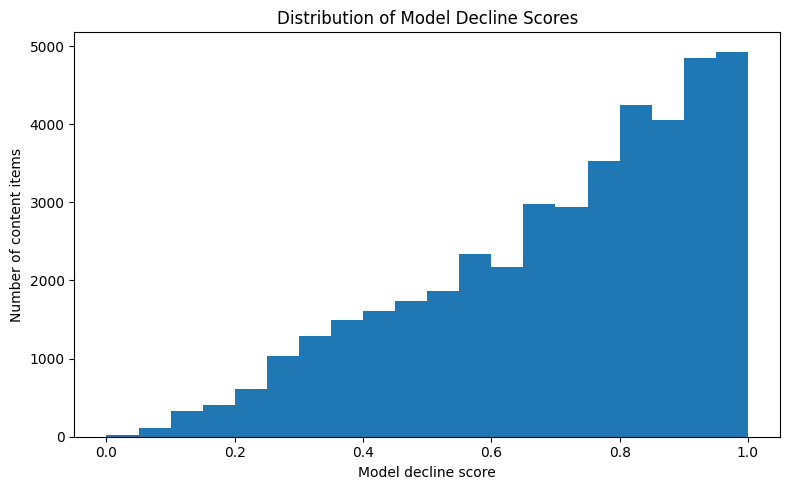

Figure saved: work/figures/w07_decline_score_distribution.png


In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    queue["decline_probability"],
    bins=20
)

plt.xlabel("Model decline score")
plt.ylabel("Number of content items")
plt.title("Distribution of Model Decline Scores")

plt.tight_layout()

figure_path = "work/figures/w07_decline_score_distribution.png"

plt.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Figure saved:", figure_path)

In [16]:
import json

metrics = {
    "validation": {
        "split": "client_grouped",
        "accuracy": 0.616,
        "precision": 0.670,
        "recall": 0.812,
        "f1": 0.735,
        "client_overlap": 0
    },
    "queue": {
        "rows": len(queue),
        "high_model_risk_count": int(
            (queue["decline_probability"] >= 0.80).sum()
        ),
        "moderate_model_risk_count": int(
            (
                (queue["decline_probability"] >= 0.60) &
                (queue["decline_probability"] < 0.80)
            ).sum()
        )
    },
    "note": (
        "Model scores are used for ranking and prioritization, "
        "not as calibrated probabilities."
    )
}

metrics_path = "work/outputs/w07_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(metrics, f, indent=2)

print("Metrics saved:", metrics_path)

Metrics saved: work/outputs/w07_metrics.json


In [17]:
import os

for path in [
    "work/outputs/w07_ranked_action_queue.csv",
    "work/outputs/w07_metrics.json",
    "work/figures/w07_decline_score_distribution.png"
]:
    print(
        path,
        "→",
        "EXISTS" if os.path.exists(path) else "MISSING"
    )

work/outputs/w07_ranked_action_queue.csv → EXISTS
work/outputs/w07_metrics.json → EXISTS
work/figures/w07_decline_score_distribution.png → EXISTS


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

In [18]:
# ---------------------------------------------------------
# 6. Self-check
# ---------------------------------------------------------

checks = {
    "Ranked queue created": len(queue) > 0,
    "Priority ranking exists": "priority_rank" in queue.columns,
    "Reason codes exist": "reason_code" in queue.columns,
    "Archetypes exist": "archetype" in queue.columns,
    "Action guidance exists": "action_guidance" in queue.columns,
    "Recommended actions exist": "recommended_action" in queue.columns,
    "Queue export exists": os.path.exists(
        "work/outputs/w07_ranked_action_queue.csv"
    ),
    "Metrics JSON exists": os.path.exists(
        "work/outputs/w07_metrics.json"
    ),
    "Paper figure exists": os.path.exists(
        "work/figures/w07_decline_score_distribution.png"
    )
}

for check, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'}: {check}")

print("\nOverall:",
      "PASS" if all(checks.values()) else "REVIEW REQUIRED")

PASS: Ranked queue created
PASS: Priority ranking exists
PASS: Reason codes exist
PASS: Archetypes exist
PASS: Action guidance exists
PASS: Recommended actions exist
PASS: Queue export exists
PASS: Metrics JSON exists
PASS: Paper figure exists

Overall: PASS
